In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

Path to dataset files: /home/lilgreg/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# Explore the dataset structure
dataset_path = path
print(f"Dataset path: {dataset_path}")
print("\nFolder structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for file in files[:2]:  # Show first 2 files
            print(f'{subindent}{file}')

Dataset path: /home/lilgreg/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8

Folder structure:
8/
  validation/
    ginger/
    turnip/
    spinach/
    orange/
    pineapple/
    eggplant/
    pear/
    sweetcorn/
    tomato/
    sweetpotato/
    grapes/
    lemon/
    kiwi/
    banana/
    paprika/
    apple/
    cucumber/
    garlic/
    cabbage/
    chilli pepper/
    lettuce/
    onion/
    soy beans/
    cauliflower/
    watermelon/
    potato/
    raddish/
    capsicum/
    corn/
    peas/
    mango/
    beetroot/
    pomegranate/
    bell pepper/
    jalepeno/
    carrot/
  test/
    ginger/
    turnip/
    spinach/
    orange/
    pineapple/
    eggplant/
    pear/
    sweetcorn/
    tomato/
    sweetpotato/
    grapes/
    lemon/
    kiwi/
    banana/
    paprika/
    apple/
    cucumber/
    garlic/
    cabbage/
    chilli pepper/
    lettuce/
    onion/
    soy beans/
    cauliflower/
    watermelon/
    potato/
    raddish/
    capsicu

In [8]:
# Define data transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load datasets from folder structure
train_dataset = datasets.ImageFolder(os.path.join(dataset_path, 'train'), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(dataset_path, 'test'), transform=val_transforms)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Display dataset information
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

Number of training samples: 3115
Number of test samples: 359
Number of classes: 36
Classes: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [9]:
# Load pre-trained ResNet18 model with transfer learning
model = models.resnet18(pretrained=True)

# Freeze early layers (keep learned features)
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Unfreeze the last layer and fc layer for fine-tuning
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print(f"Model loaded and moved to {device}")
print(f"Final layer updated to output {num_classes} classes")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam (lr=0.001)")

/home/lilgreg/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lilgreg/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded and moved to cuda
Final layer updated to output 36 classes
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


In [10]:
# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': running_loss / total, 'acc': 100 * correct / total})
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

print("Training and validation functions defined!")

Training and validation functions defined!


In [12]:
# Train the model
num_epochs = 15
best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, _, _ = validate(model, test_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_fruit_veg_model.pth')
        print("✓ Best model saved!")
    
    # Adjust learning rate
    scheduler.step(val_loss)

print("\nTraining complete!")


Epoch 1/15
--------------------------------------------------


Training:   8%|▊         | 8/98 [00:07<01:20,  1.11it/s, loss=0.113, acc=5.08]


KeyboardInterrupt: 

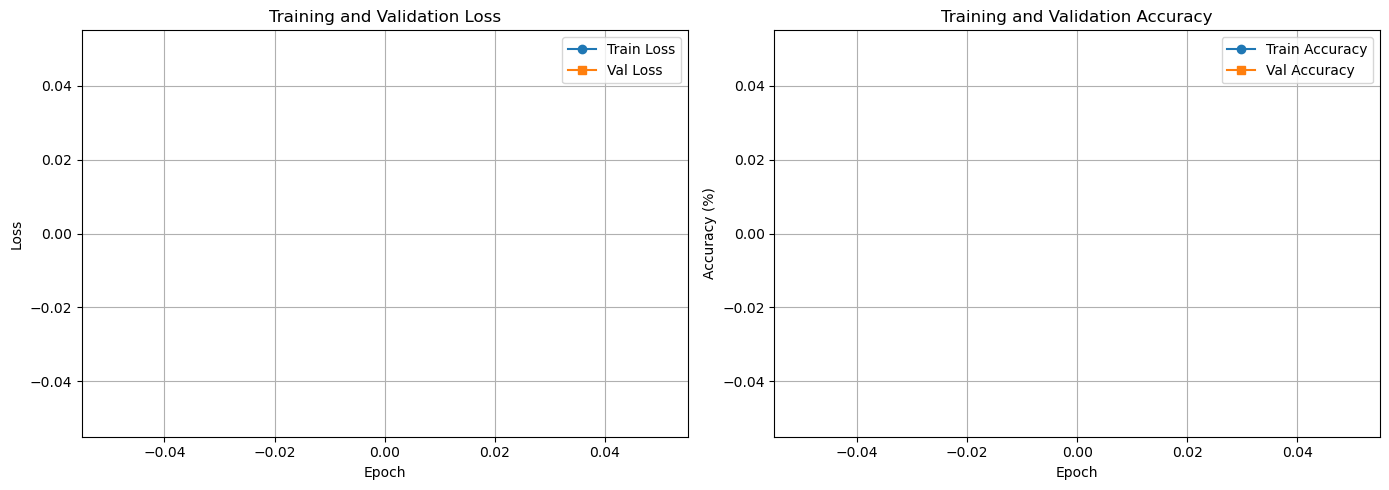

Best validation accuracy: 0.00%


In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {best_acc:.2f}%")

Final Model Evaluation

Classification Report:
               precision    recall  f1-score   support

        apple       0.88      0.70      0.78        10
       banana       1.00      0.78      0.88         9
     beetroot       1.00      0.90      0.95        10
  bell pepper       0.73      0.80      0.76        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.55      0.60      0.57        10
       carrot       1.00      1.00      1.00        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.60      0.90      0.72        10
         corn       1.00      0.60      0.75        10
     cucumber       1.00      1.00      1.00        10
     eggplant       1.00      1.00      1.00        10
       garlic       0.91      1.00      0.95        10
       ginger       1.00      1.00      1.00        10
       grapes       1.00      1.00      1.00        10
     jalepeno       0.69      0.90      0.78        10
         kiwi    

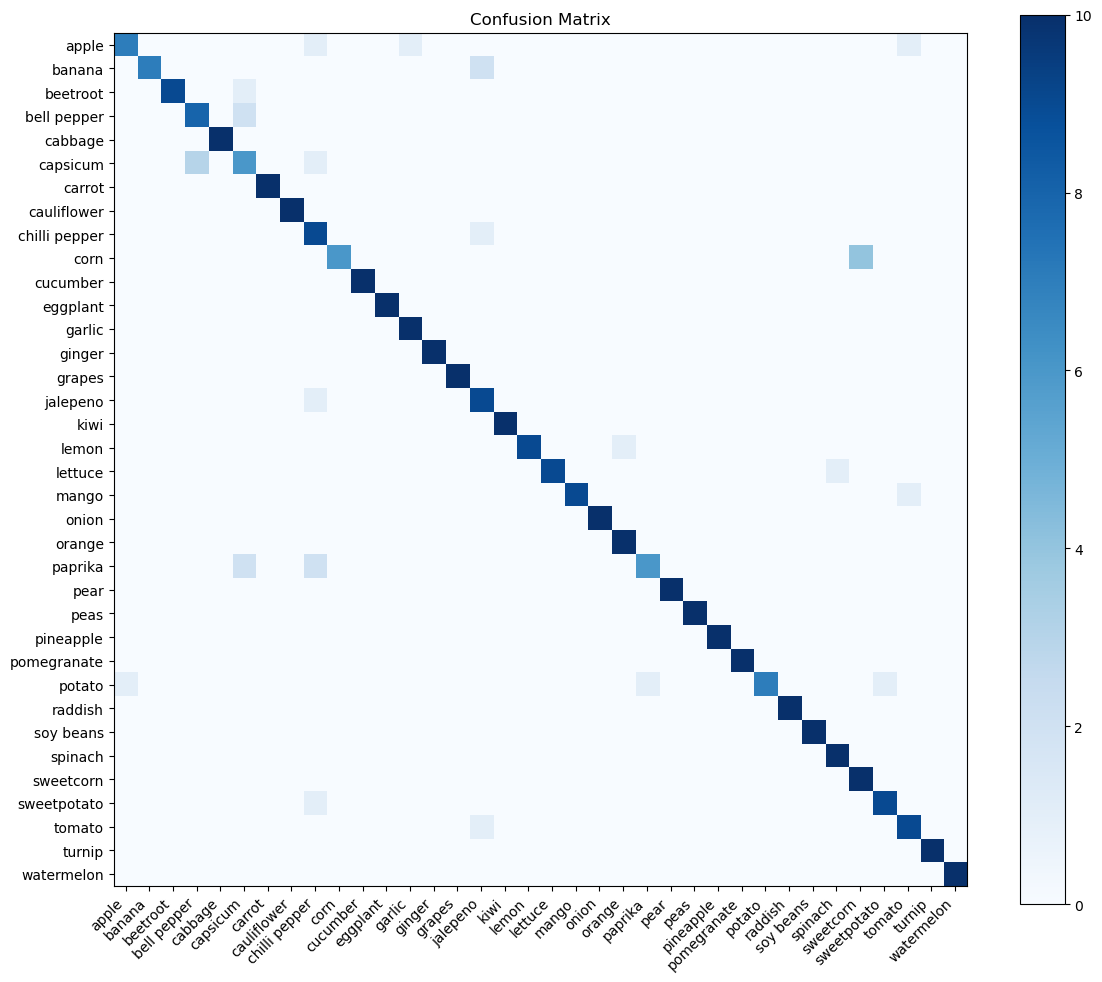

In [14]:
# Final evaluation on test set
print("Final Model Evaluation")
print("=" * 50)

# Load best model
model.load_state_dict(torch.load('fruit_and_veg_model.pth'))

# Get predictions
_, _, all_preds, all_labels = validate(model, test_loader, criterion, device)

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix visualization
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(train_dataset.classes)), train_dataset.classes, rotation=45, ha='right')
plt.yticks(range(len(train_dataset.classes)), train_dataset.classes)
plt.tight_layout()
plt.show()

In [15]:
# Function to make predictions on new images
def predict_image(image_path, model, class_names, device):
    """Predict the fruit/vegetable in a single image"""
    model.eval()
    
    # Load and transform image
    image = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])(Image.open(image_path).convert('RGB'))
    
    image = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_pred = torch.argmax(probabilities, 1)
    
    predicted_class = class_names[top_pred.item()]
    confidence = probabilities[0][top_pred].item() * 100
    
    return predicted_class, confidence, probabilities[0].cpu().numpy()

# Example usage (uncomment if you have an image to test)
from PIL import Image
image_path = "/home/lilgreg/ML/Fruit_n_veg_classifier/cucumba.jpeg"
pred_class, confidence, _ = predict_image(image_path, model, train_dataset.classes, device)
print(f"Prediction: {pred_class} (Confidence: {confidence:.2f}%)")

Prediction: jalepeno (Confidence: 46.24%)


In [16]:
import torch
import cv2 as cv
import numpy
from PIL import Image
from torchvision import transforms

def predict_frame(frame, model, class_names, device):
    """Predict the fruit/vegetable in an OpenCV frame"""
    model.eval()
    
    # 1. Convert BGR (OpenCV) to RGB
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    
    # 2. Convert NumPy array to PIL Image 
    # (This makes it compatible with your existing torchvision transforms)
    pil_image = Image.fromarray(frame_rgb)
    
    # 3. Apply your preprocessing pipeline
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    image_tensor = preprocess(pil_image).unsqueeze(0).to(device)
    
    # 4. Inference
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_pred = torch.argmax(probabilities, 1)
    
    predicted_class = class_names[top_pred.item()]
    confidence = probabilities[0][top_pred].item() * 100
    
    return predicted_class, confidence

In [21]:

 
##
# Opens a video capture device with a resolution of 800x600
# at 30 FPS.
##
def open_camera(cam_id = 0):
    cap = cv.VideoCapture(cam_id)
    cap.set(cv.CAP_PROP_FRAME_HEIGHT, 600)
    cap.set(cv.CAP_PROP_FRAME_WIDTH, 800)
    cap.set(cv.CAP_PROP_FPS, 30)
    return cap
 
##
# Gets a frame from an open video device, or returns None
# if the capture could not be made.
##
def get_frame(device):
    ret, img = device.read()
    if (ret == False): # failed to capture
        print("Failed to capture from camera. Check if it is connected and try again.")
        return None
    return img
 
##
# Closes all OpenCV windows and releases video capture device
# before exit.
##
def cleanup(cam_id = 0): 
    cv.destroyAllWindows()
    cv.VideoCapture(cam_id).release()
 
##
# Creates a new RGB image of the specified size, initially
# filled with black.
##
def new_rgb_image(width, height):
    image = numpy.zeros( (height, width, 3), numpy.uint8)
    return image

########### Main Program ###########

if __name__ == "__main__":
    # Camera ID to read video from (numbered from 0)
    camera_id = 0
    dev = open_camera(camera_id) # open the camera as a video capture device
    # Prepare an incremental filename counter by scanning existing captures

    while True:
        img_orig = get_frame(dev) # Get a frame from the camera
        if img_orig is not None: # if we did get an image
            cv.imshow("video", img_orig) # display the image in a window named "video"
            
        else: # if we failed to capture (camera disconnected?), then quit
            break

        pred_class, confidence= predict_frame(img_orig, model, train_dataset.classes, device)
        print(f"Prediction: {pred_class} (Confidence: {confidence:.2f}%)")

        key = cv.waitKey(1) # wait for 1 ms for a key press
        if key == 27: # if the key was ESC, then quit   
            break
 
    cleanup(camera_id) # close video device and windows before we exit


QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is not the object's thread (0x4d2578c0).
Cannot move to target thread (0x4cf0d220)

QObject::moveToThread: Current thread (0x4cf0d220) is n

Prediction: raddish (Confidence: 15.17%)
Prediction: mango (Confidence: 14.96%)
Prediction: mango (Confidence: 15.60%)
Prediction: raddish (Confidence: 14.19%)
Prediction: raddish (Confidence: 16.01%)
Prediction: mango (Confidence: 15.26%)
Prediction: mango (Confidence: 16.33%)
Prediction: mango (Confidence: 15.80%)
Prediction: raddish (Confidence: 15.45%)
Prediction: raddish (Confidence: 15.10%)
Prediction: raddish (Confidence: 13.58%)
Prediction: mango (Confidence: 12.93%)
Prediction: mango (Confidence: 13.98%)
Prediction: mango (Confidence: 12.99%)
Prediction: mango (Confidence: 12.55%)
Prediction: mango (Confidence: 13.14%)
Prediction: mango (Confidence: 11.35%)
Prediction: raddish (Confidence: 13.41%)
Prediction: mango (Confidence: 12.54%)
Prediction: mango (Confidence: 12.41%)
Prediction: mango (Confidence: 14.56%)
Prediction: raddish (Confidence: 13.34%)
Prediction: mango (Confidence: 13.61%)
Prediction: mango (Confidence: 13.06%)
Prediction: mango (Confidence: 11.36%)
Predictio

[ WARN:0@278.812] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[video4linux2,v4l2 @ 0x49b9f180] ioctl(VIDIOC_G_INPUT): Inappropriate ioctl for device
[ERROR:0@278.813] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
